# 📺 Predicting Time-to-Netflix:
## A Regression Analysis of Content Acquisition Lag

---

### 🎯 Project Goal

When a movie or TV show is released, it does not immediately become available on Netflix.
Some titles appear within a few months, while others take several years.

The objective of this project is to build a regression model capable of predicting the **Content Acquisition Lag**, defined as the number of years between a title's original release and the date it was added to Netflix.

Instead of focusing solely on model accuracy, this notebook emphasizes:

- Understanding the dataset
- Feature Engineering
- Data Cleaning
- Model Development
- Model Interpretation
- Limitations of the approach

This notebook follows an end-to-end machine learning workflow.

## Problem Statement

Can we estimate how long it will take for a movie or TV show to appear on Netflix using only its metadata?

Target Variable

Content Acquisition Lag

Acquisition Lag = Year(Date Added) − Release Year

This is a supervised regression problem because the target variable is continuous.

## Dataset

Source:
Netflix Movies and TV Shows Dataset (Snapshot: September 2021)

The dataset contains metadata for over 8,800 Netflix titles including:

• Director
• Cast
• Country
• Release Year
• Date Added
• Content Rating
• Duration
• Genres
• Description

The dataset does not contain:

❌ User ratings
❌ Popularity
❌ Watch time
❌ Revenue

## Assumptions

This project assumes:

• The release year represents the title's first public release.

• The year extracted from date_added represents the acquisition year.

• Missing metadata is handled during preprocessing.

• Predictions are based solely on publicly available metadata.

## Success Criteria

Model performance will be evaluated using:

• Mean Absolute Error (MAE)

• Root Mean Squared Error (RMSE)

• R² Score

## 🗺️ How We'll Approach This Project

Rather than jumping straight into building a model, we'll first understand the data, identify potential issues, engineer meaningful features, and then train a regression model to predict the content acquisition lag.

Here's the journey we'll follow:

- Understand the dataset
- Explore the data and look for patterns
- Clean and prepare the data
- Engineer useful features
- Build a baseline Linear Regression model
- Evaluate the model's performance
- Discuss the results and possible improvements

In [1]:
#DATA MANIPULATION
import pandas as pd
import numpy as np
#visualization
import matplotlib.pyplot as plt
import seaborn as sns
#machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import warnings
warnings.filterwarnings("ignore")

# Better plot aesthetics
plt.style.use("ggplot")


In [2]:
df=pd.read_csv("/kaggle/input/datasets/sunil123kumar/netflix-movies-and-tv-shows-dataset/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.shape

(8807, 12)

In [4]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


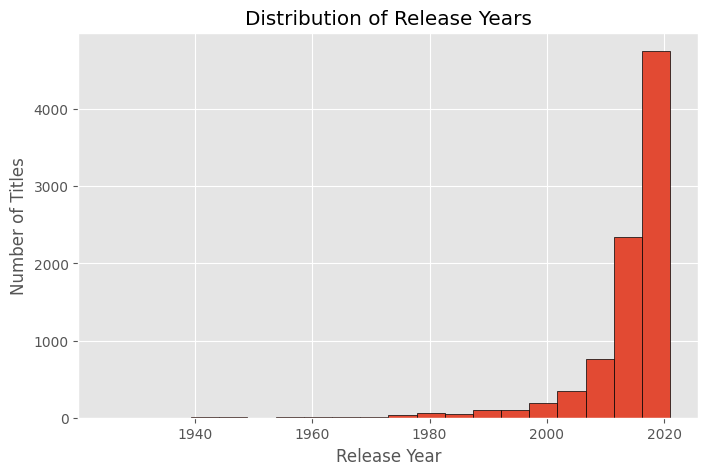

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['release_year'], bins=20, edgecolor='black')
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.title("Distribution of Release Years")
plt.show()

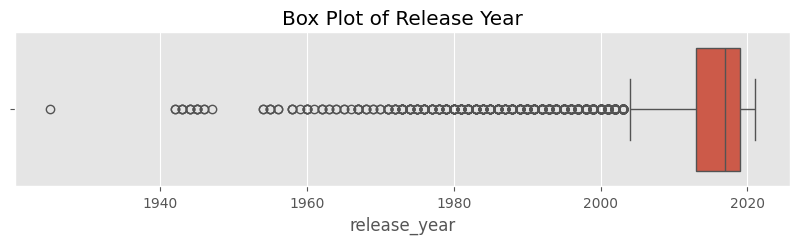

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,2))
sns.boxplot(x=df["release_year"])
plt.title("Box Plot of Release Year")
plt.show()

<Axes: xlabel='release_year', ylabel='Count'>

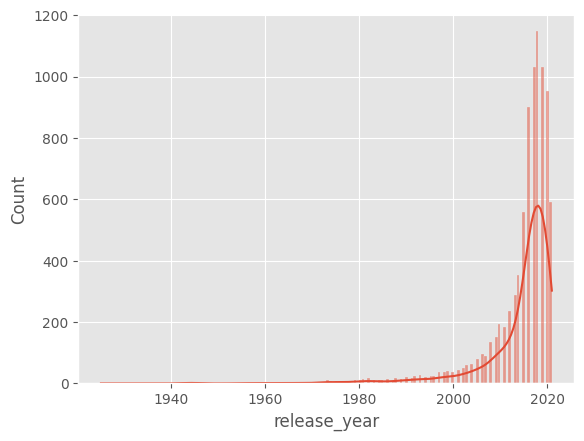

In [9]:
sns.histplot(df["release_year"], kde=True)

<Axes: xlabel='rating'>

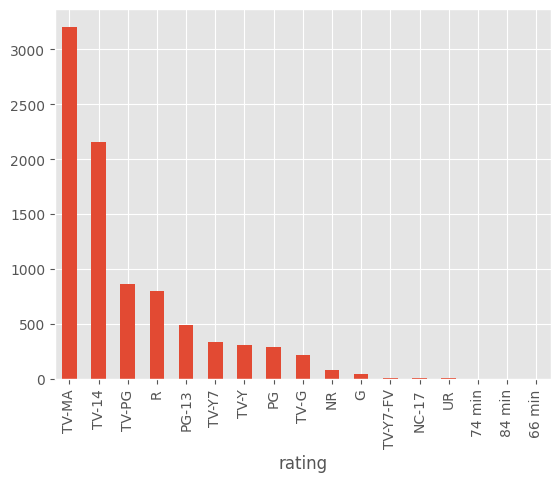

In [10]:
df["rating"].value_counts().plot(kind="bar")

In [11]:
df[df["rating"].str.contains("min", na=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [12]:
# Missing values
df.isnull().sum()



show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:


# Check missing values
print("Missing Values Before Cleaning:\n")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Fill missing categorical values
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")

# Since only 10 rows have missing 'date_added',
# removing them has negligible impact.
df.dropna(subset=["date_added"], inplace=True)

# Fill missing ratings with the most frequent rating
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

# Remove rows with missing duration (only 3 rows)
df.dropna(subset=["duration"], inplace=True)

# Reset index after cleaning
df.reset_index(drop=True, inplace=True)

# Verify the cleaned dataset
print("\nMissing Values After Cleaning:\n")
print(df.isnull().sum())

print("\nDataset Shape:", df.shape)

Missing Values Before Cleaning:

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Duplicate Rows: 0

Missing Values After Cleaning:

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

Dataset Shape: (8794, 12)


In [15]:
# Clean whitespace
df["date_added"] = df["date_added"].astype(str).str.strip()

# Convert to datetime
df["date_added"] = pd.to_datetime(
    df["date_added"],
    format="%B %d, %Y",
    errors="coerce"
)

# Check if any rows failed
print("Failed conversions:", df["date_added"].isna().sum())

# Extract features
df["added_year"] = df["date_added"].dt.year
df["added_month"] = df["date_added"].dt.month

Failed conversions: 0


## Date Feature Engineering

The `date_added` column was cleaned by removing leading and trailing whitespace, converted from a string to a datetime object using an explicit date format, and then decomposed into useful temporal features such as `added_year` and `added_month`.

In [16]:
print(df["date_added"].dtype)

df[["date_added", "added_year", "added_month"]].head()

datetime64[ns]


,date_added,added_year,added_month
0,2021-09-25,2021,9
1,2021-09-24,2021,9
2,2021-09-24,2021,9
3,2021-09-24,2021,9
4,2021-09-24,2021,9


In [17]:
df["content_acquisition_lag"] = (
    df["added_year"] - df["release_year"]
) #target variable

In [18]:
print(df["content_acquisition_lag"].describe())

count    8794.000000
mean        4.689220
std         8.788256
min        -3.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        93.000000
Name: content_acquisition_lag, dtype: float64


In [19]:
model_df = df[[
    "release_year",
    "added_month",
    "type",
    "rating",
    "content_acquisition_lag"
]].copy()

In [20]:
model_df.head()

,release_year,added_month,type,rating,content_acquisition_lag
0,2020,9,Movie,PG-13,1
1,2021,9,TV Show,TV-MA,0
2,2021,9,TV Show,TV-MA,0
3,2021,9,TV Show,TV-MA,0
4,2021,9,TV Show,TV-MA,0


In [21]:
# Separate features and target
X = model_df.drop("content_acquisition_lag", axis=1)
y = model_df["content_acquisition_lag"]

In [22]:
print("Features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

Features (X):


,release_year,added_month,type,rating
0,2020,9,Movie,PG-13
1,2021,9,TV Show,TV-MA
2,2021,9,TV Show,TV-MA
3,2021,9,TV Show,TV-MA
4,2021,9,TV Show,TV-MA



Target (y):


0    1
1    0
2    0
3    0
4    0
Name: content_acquisition_lag, dtype: int64

In [23]:
print(X.head())
print(y.head())

   release_year  added_month     type rating
0          2020            9    Movie  PG-13
1          2021            9  TV Show  TV-MA
2          2021            9  TV Show  TV-MA
3          2021            9  TV Show  TV-MA
4          2021            9  TV Show  TV-MA
0    1
1    0
2    0
3    0
4    0
Name: content_acquisition_lag, dtype: int64


In [24]:
X = pd.get_dummies(
    X,
    columns=["type", "rating"],
    drop_first=True
)

In [25]:
print(X.columns.tolist())

['release_year', 'added_month', 'type_TV Show', 'rating_NC-17', 'rating_NR', 'rating_PG', 'rating_PG-13', 'rating_R', 'rating_TV-14', 'rating_TV-G', 'rating_TV-MA', 'rating_TV-PG', 'rating_TV-Y', 'rating_TV-Y7', 'rating_TV-Y7-FV', 'rating_UR']


In [26]:
X = X.astype(int)
X.head()#one hot encoding done


,release_year,added_month,type_TV Show,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR
0,2020,9,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,2021,9,1,0,0,0,0,0,0,0,1,0,0,0,0,0
2,2021,9,1,0,0,0,0,0,0,0,1,0,0,0,0,0
3,2021,9,1,0,0,0,0,0,0,0,1,0,0,0,0,0
4,2021,9,1,0,0,0,0,0,0,0,1,0,0,0,0,0


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [29]:
y_pred = model.predict(X_test)
print(y_pred)

[ 1.84781166  0.22995248 -0.24175723 ...  2.05479933  2.78764452
 -0.73125844]


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R² Score:", r2_score(y_test, y_pred))

MAE : 1.2384327737569243
MSE : 2.3207391496093592
RMSE: 1.5233972395962123
R² Score: 0.9768774717899504


In [31]:
print("Train R²:", model.score(X_train, y_train))
print("Test R² :", model.score(X_test, y_test))

Train R²: 0.9689185344648656
Test R² : 0.9768774717899504


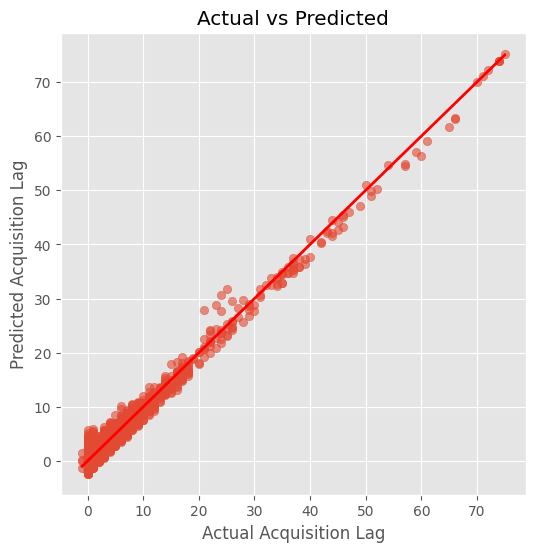

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Acquisition Lag")
plt.ylabel("Predicted Acquisition Lag")
plt.title("Actual vs Predicted")

plt.show()

## 📌 Conclusion

The **Actual vs Predicted** plot shows that most data points lie close to the ideal diagonal line, indicating that the Linear Regression model has successfully learned the relationship between the selected features and the **content acquisition lag**. The small deviations from the line represent prediction errors, which are consistent with the model's low **Mean Absolute Error (MAE = 1.24 years)** and high **R² Score (0.9769)**.

Additionally, the **Train R² (0.9689)** and **Test R² (0.9769)** are very close, suggesting that the model generalizes well to unseen data and shows no clear signs of overfitting.

Overall, the model demonstrates strong predictive performance on this Netflix dataset. While the results are encouraging, they should be interpreted within the scope of the available features, as real-world factors such as licensing agreements, regional availability, and business decisions may also influence Netflix's content acquisition timeline.

## 📌 Final Thoughts

This notebook was more than building a Linear Regression model—it was an exercise in developing machine learning intuition.

Throughout this project, I practiced the complete ML workflow:
- Understanding the dataset through Exploratory Data Analysis (EDA)
- Cleaning missing values and preparing real-world data
- Engineering meaningful features from existing information
- Selecting relevant features for modeling
- Applying One-Hot Encoding to categorical variables
- Training and evaluating a Linear Regression model
- Interpreting evaluation metrics and visualizing predictions

Instead of treating each concept as an isolated topic, this notebook connected them into a single end-to-end pipeline. Every step answered a practical question: *Why is this step necessary? What does it contribute to the final model?*

Most importantly, this project strengthened my intuition for how machine learning is applied to real datasets. It reinforced that building models is not only about writing code—it is about understanding data, making informed decisions, and interpreting results critically.

This notebook marks another step in my journey toward becoming a better machine learning researcher, one project at a time.